### Compare why even with correct Hypers Jax is flopping
- Run Jax fit
- Give fgpgm hypers from jax
- Compare Kernel Methods
- ???

In [66]:
# Adjust import path
import sys
sys.path.append("../ODEs")
sys.path.append("../")

In [67]:
# Imports
import os
import itertools
import math
import numpy as np
import matplotlib.pyplot as plt

import opinf

import utils
import config_lotka_volterra as config
import step1_generate_data as step1
import step3_estimate as step3
import step4_plot as step4
import numpy as np
import random

seed = 21092023  # Or any integer you prefer

np.random.seed(seed)
random.seed(seed)
%load_ext autoreload
%autoreload 2
import importlib
import sys

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Create Data

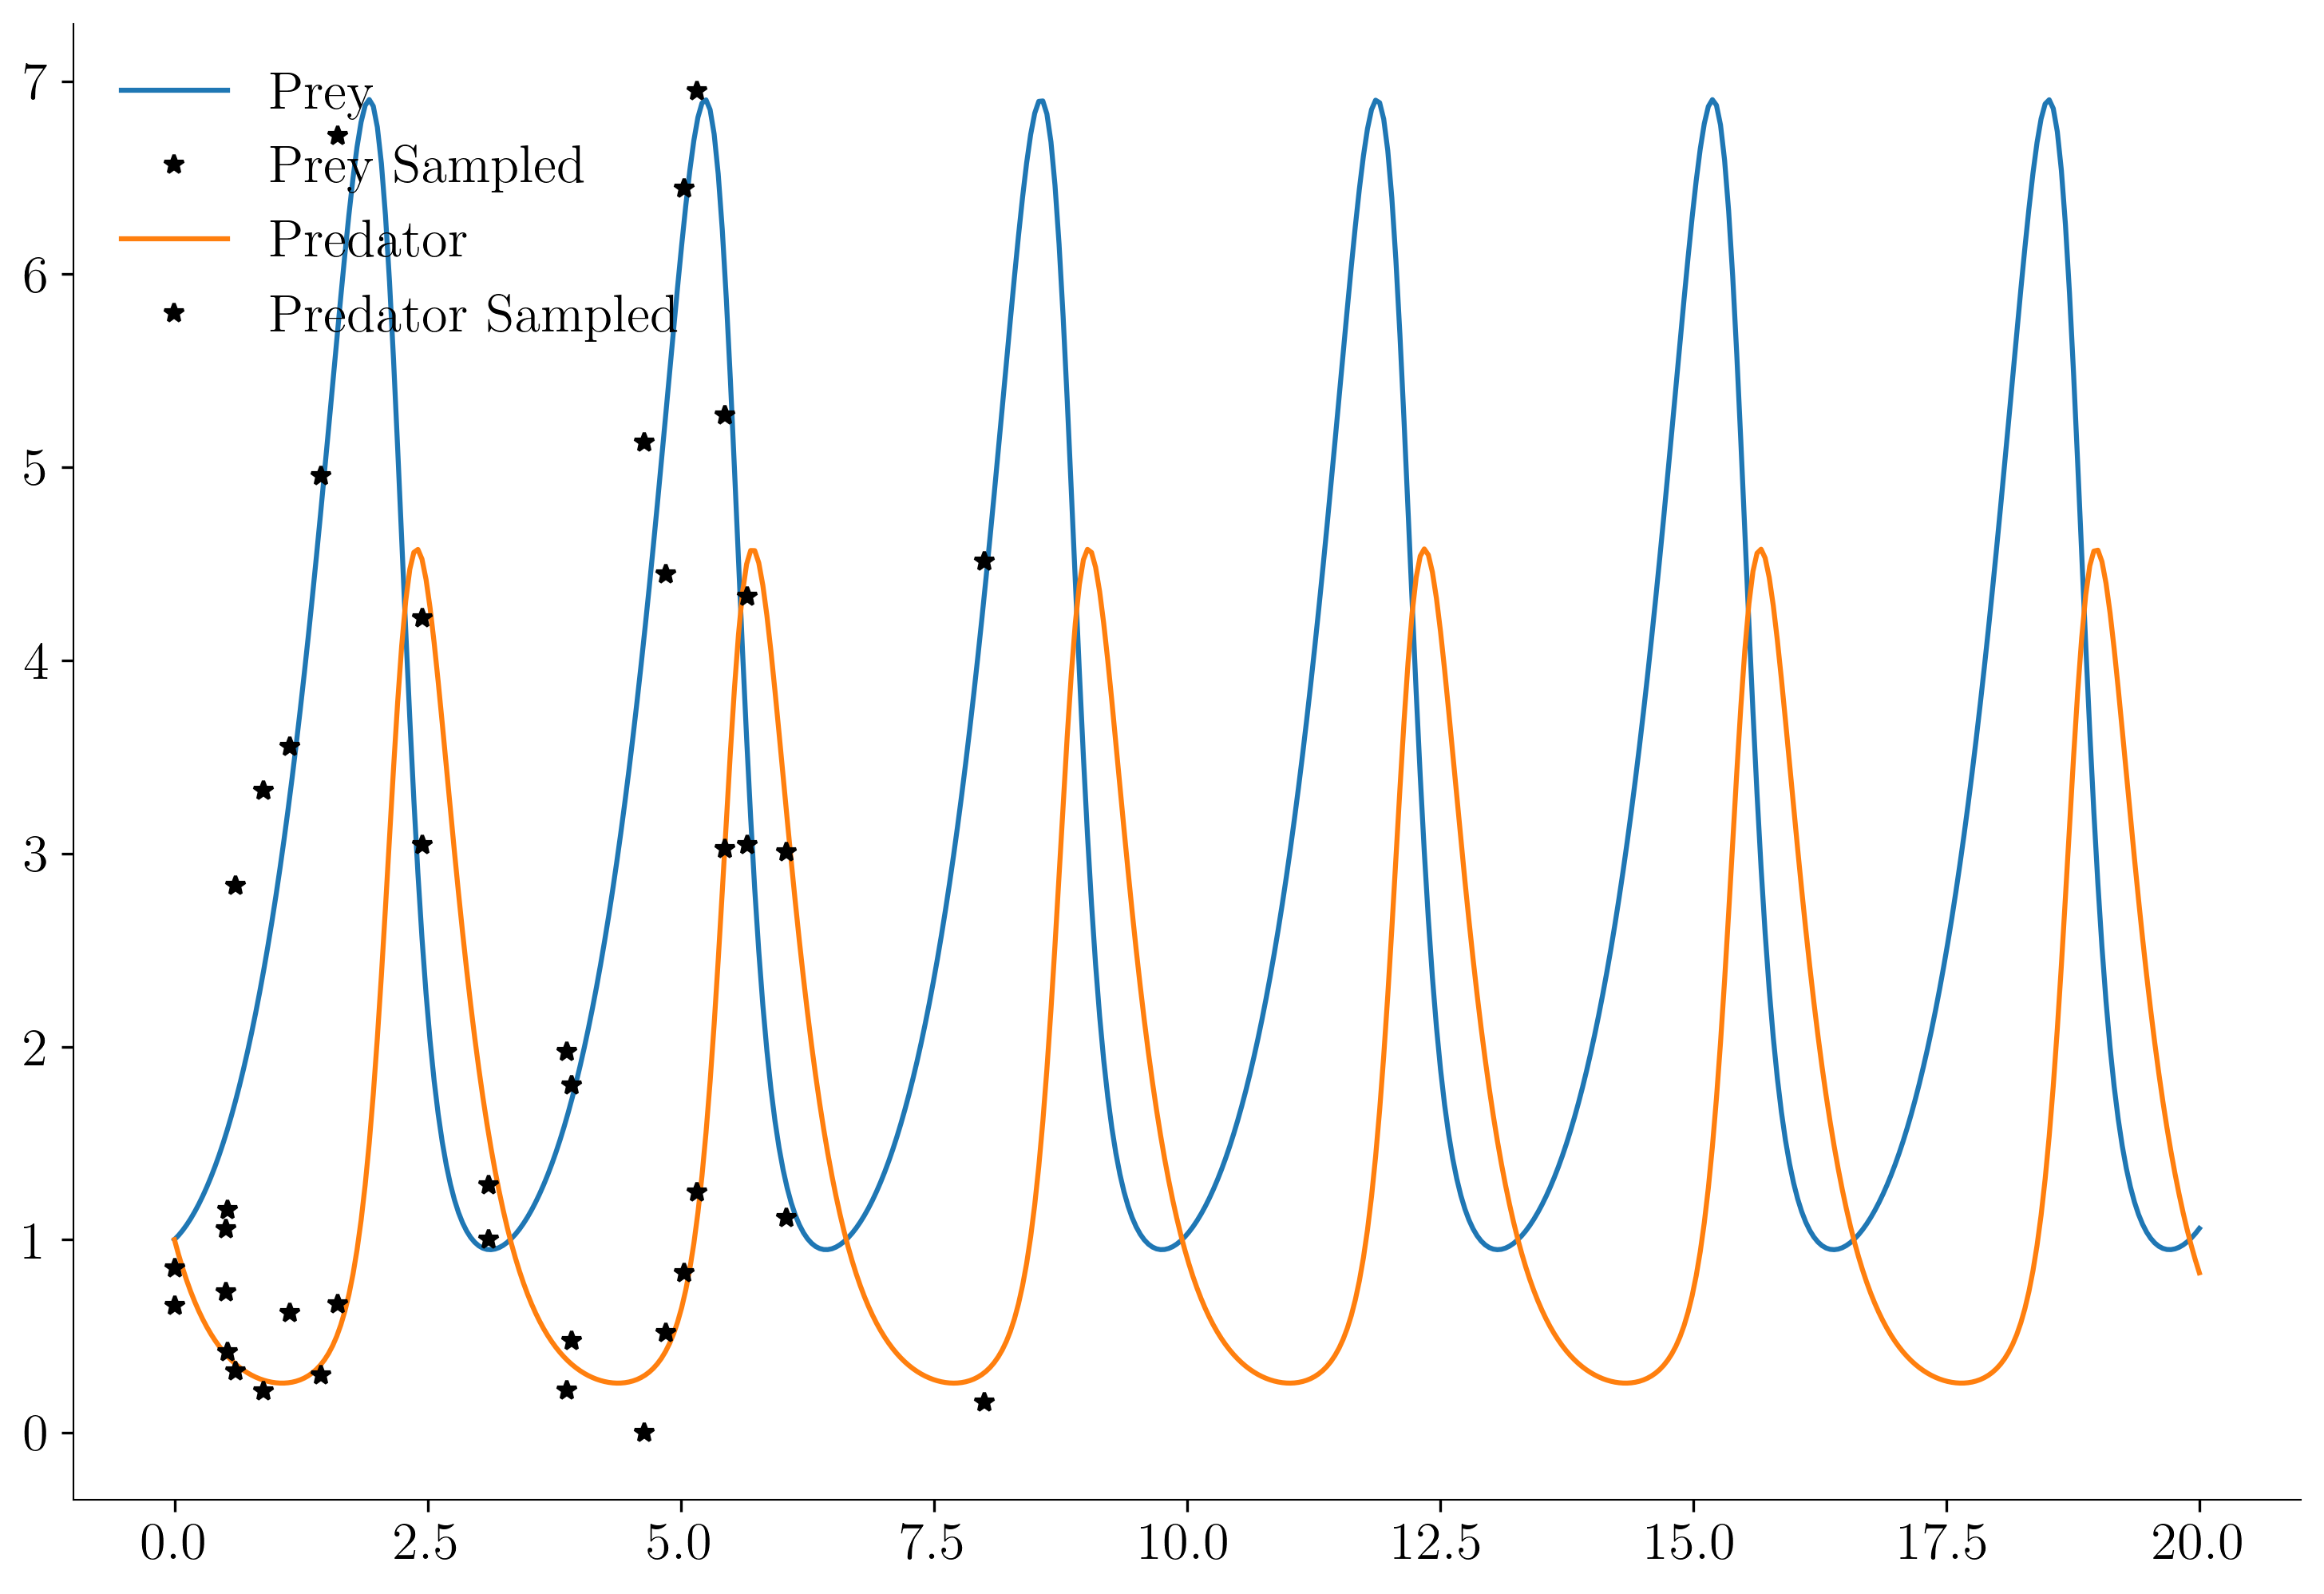

In [68]:
training_span = (0,8)
num_samples = 20
noiselevel = .2
num_regression_points = 300
# Step 1: Generate data ---------------------------------------------------
config.alpha, config.beta, config.gamma, config.delta = 1.5, 1, 3, 1
sampler = step1.TrajectorySampler(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    synced=True,
    integersonly=False,
    config=config,
)

(
    truthmodel,
    time_domain_prediction,
    true_states,
    time_domains_sampled,
    snapshots_sampled,
) = sampler.sample()
true_parameters = np.copy(truthmodel.parameters)

num_vars = len(true_states)
for i in range(num_vars):
    plt.plot(time_domain_prediction, true_states[i], label='Prey' if i == 0 else 'Predator')
    plt.plot(time_domains_sampled[i], snapshots_sampled[i], 'k*', label='Prey Sampled' if i == 0 else 'Predator Sampled')
plt.legend()
plt.show()

### Train GPS

In [69]:
import numpy as np
from RBF import RBF
import os

from matplotlib import pyplot as plt

# decide if the data should be standardized in a preprocessing step
standardize = True

"""kernel optimization"""
# amount of basinhopping iterations in kernel hyperparameter optimization
kernelIter = 100  # should be adjusted based on roughness of likelihood
optimizer = 'basinhopping'
gammaValue = 3e-1
gammaValues = np.asarray(gammaValue).reshape([-1, 1])

y = np.array(snapshots_sampled).transpose(1,0)
time = np.array(time_domains_sampled)[0]
print(time.shape)

"""create Kernel and Kernel matrices"""
kernel = RBF(theta=np.abs(np.random.randn(2)),
             sigma=np.abs(np.random.randn(1)))
kernel.learnHyperparams(
    kernel.theta,
    kernel.sigma,
    y,
    time,
    normalize=True,
    standardize=standardize,
    newNugget=1e-4,
    anneal=False,
    basinIter=kernelIter,
    optimizer=optimizer
    )

(20,)
[(0.0001, np.float64(48.287231045548396)), (np.float64(0.5050484674059952), np.float64(50.50484674059952)), (0.001, np.float64(6.9489014272436185))]
[(0.0001, np.float64(48.287231045548396)), (np.float64(0.5050484674059952), np.float64(50.50484674059952)), (0.001, np.float64(6.9489014272436185))]
using L-BFGS-B as hyperparameter optimizer with basin hopping
YES: 0.40954553402682536 @ [1.13046306 0.50504847 0.29435   ]
Nope: 2.000198932879238 @ [1.00000000e-04 5.05048467e+01 9.99999475e-01]
Nope: 2.000198174779393 @ [1.00000000e-04 3.67505804e+01 9.99998141e-01]
Nope: 2.0001819042642053 @ [1.00000000e-04 1.07572924e+01 9.99990941e-01]
Nope: 2.0001988418324705 @ [1.00000000e-04 4.80128904e+01 9.99999396e-01]
YES: 2.000195796866679 @ [1.00000000e-04 2.32881857e+01 9.99997903e-01]
YES: 2.000198932879239 @ [1.00000000e-04 5.05048467e+01 9.99999485e-01]
YES: 2.000198221198521 @ [1.00000000e-04 3.72929450e+01 9.99999097e-01]
YES: 2.000198570277698 @ [1.00000000e-04 4.23158468e+01 9.9999

In [70]:
theta = np.asarray(kernel.theta)
sigma = np.asarray(kernel.sigma).reshape([1,1])
print(theta, sigma)

[1.13046232 0.50504847] [[0.29435005]]


In [71]:
### Standardize the data
y = np.array(snapshots_sampled) # Shape (2,n)
print(y.shape)
time = np.array(time_domains_sampled)[0][:,None] # Shape (20,1)
y_mean = y.mean(axis=1).reshape(2,1).repeat(time.size, axis=1)
y_std = y.std(axis=1).reshape(2,1).repeat(time.size, axis=1)
y_standard = (y - y_mean) / y_std  # Shape (2,n)

(2, 20)


In [72]:
import jax
import jax.numpy as jnp
from jax import debug
from functools import partial

# 1) RBF kernel
@jax.jit
def rbf_kernel(x1: jnp.ndarray,
               x2: jnp.ndarray,
               lengthscale: float,
               variance: float) -> jnp.ndarray:
    """
    x1: [N, D], x2: [M, D]
    returns K: [N, M] with
    K_ij = variance * exp(-0.5 * ||x1[i]-x2[j]||^2 / lengthscale^2)
    """
    # compute (x1[:,None,:] - x2[None,:,:])**2 summed over last axis
    sqdist = jnp.sum((x1[:, None, :] - x2[None, :, :])**2, axis=-1)
    return variance * jnp.exp(-0.5 * sqdist / (lengthscale**2))


# 2) Log marginal likelihood
@partial(jax.jit, static_argnums=(3,))
def log_marginal_likelihood(params: dict,
                            X: jnp.ndarray,
                            y: jnp.ndarray,
                            standardize: bool) -> float:
    """
    params: {'lengthscale': l, 'variance': σ_f^2, 'noise': σ_n^2}
    X: [N, D], y: [N]
    """
    l = params['lengthscale']
    scale = params['variance']
    noise = params['noise']
    N = X.shape[0]

    K = rbf_kernel(X, X, l, scale) + noise * jnp.eye(N)
    L = jnp.linalg.cholesky(K)

    # Standardize
    if standardize:
        y = (y - jnp.mean(y)) / jnp.std(y)

    # alpha = K^{-1} y via Cholesky solves
    alpha = jax.scipy.linalg.cho_solve((L, True), y)

    log_lik = -0.5 * y @ alpha \
              - jnp.sum(jnp.log(jnp.diag(L))) \
              - 0.5 * N * jnp.log(2 * jnp.pi)
    return log_lik


# 3) Posterior predictive
@partial(jax.jit, static_argnums=())
def gp_predict(params: dict,
               X_train: jnp.ndarray,
               y_train: jnp.ndarray,
               X_test:  jnp.ndarray) -> tuple[jnp.ndarray, jnp.ndarray]:
    """
    Returns predictive mean [M] and covariance [M, M] at X_test.
    mu(x*) = k(x*, x) * [k(x,x) + (sigma**2 * I)]^-1 * y
    cov(x*) = k(x*, x*) - k(x*,x) * [k(x,x) + (sigma**2 * I)]^-1 * k(x,x*)
    """
    l = params['lengthscale']
    scale = params['variance']
    noise = params['noise']

    # Train covariance
    K = rbf_kernel(X_train, X_train, l, scale) + noise * jnp.eye(X_train.shape[0])
    L = jnp.linalg.cholesky(K)

    # Compute α = K^{-1} y_train
    alpha = jax.scipy.linalg.cho_solve((L, True), y_train)

    # Cross-covariances
    K_s = rbf_kernel(X_train, X_test, l, scale)

    # Predictive mean
    mu = K_s.T @ alpha

    # Solve L v = K_s  for v
    v = jax.scipy.linalg.solve_triangular(L, K_s, lower=True)

    # Predictive covariance
    K_ss = rbf_kernel(X_test, X_test, l, scale)
    cov = K_ss - v.T @ v

    return mu, cov

In [73]:
import optax

# Define Bounds
# your bounds
a_l, b_l = 1e-3, 1e2
a_v, b_v = 1e-6, 1e2
a_n, b_n = 1e-8, 1e-0

# 1) Define the raw→[a,b] transform
def bounded(raw, a, b):
    """Map real→(a,b) via sigmoid."""
    return a + (b - a) * jax.nn.sigmoid(raw)

def inv_bounded(f, a, b):
    # f must lie strictly between a and b
    y = (f - a) / (b - a)
    return jnp.log(y / (1 - y))

def raw_to_params(raw):
    return {
      'lengthscale': bounded(raw['u_l'], a_l, b_l),
      'variance':    bounded(raw['u_v'], a_v, b_v),
      'noise':       bounded(raw['u_n'], a_n, b_n),
    }

def params_to_raw(params):
    return{
        'u_l': inv_bounded(params['lengthscale'],    a_l, b_l),
        'u_v': inv_bounded(params['variance'],    a_v, b_v),
        'u_n': inv_bounded(params['noise'],   a_n, b_n),
    }

Iter   0, neg-log-lik = 210.5656
Iter  10, neg-log-lik = 156.4748
Iter  20, neg-log-lik = 119.4882
Iter  30, neg-log-lik = 97.5483
Iter  40, neg-log-lik = 84.5858
Iter  50, neg-log-lik = 76.1424
Iter  60, neg-log-lik = 70.0093
Iter  70, neg-log-lik = 65.1790
Iter  80, neg-log-lik = 61.1809
Iter  90, neg-log-lik = 57.7901
{'lengthscale': Array(0.5602605, dtype=float32), 'variance': Array(1.7500963, dtype=float32), 'noise': Array(0.01883809, dtype=float32)}


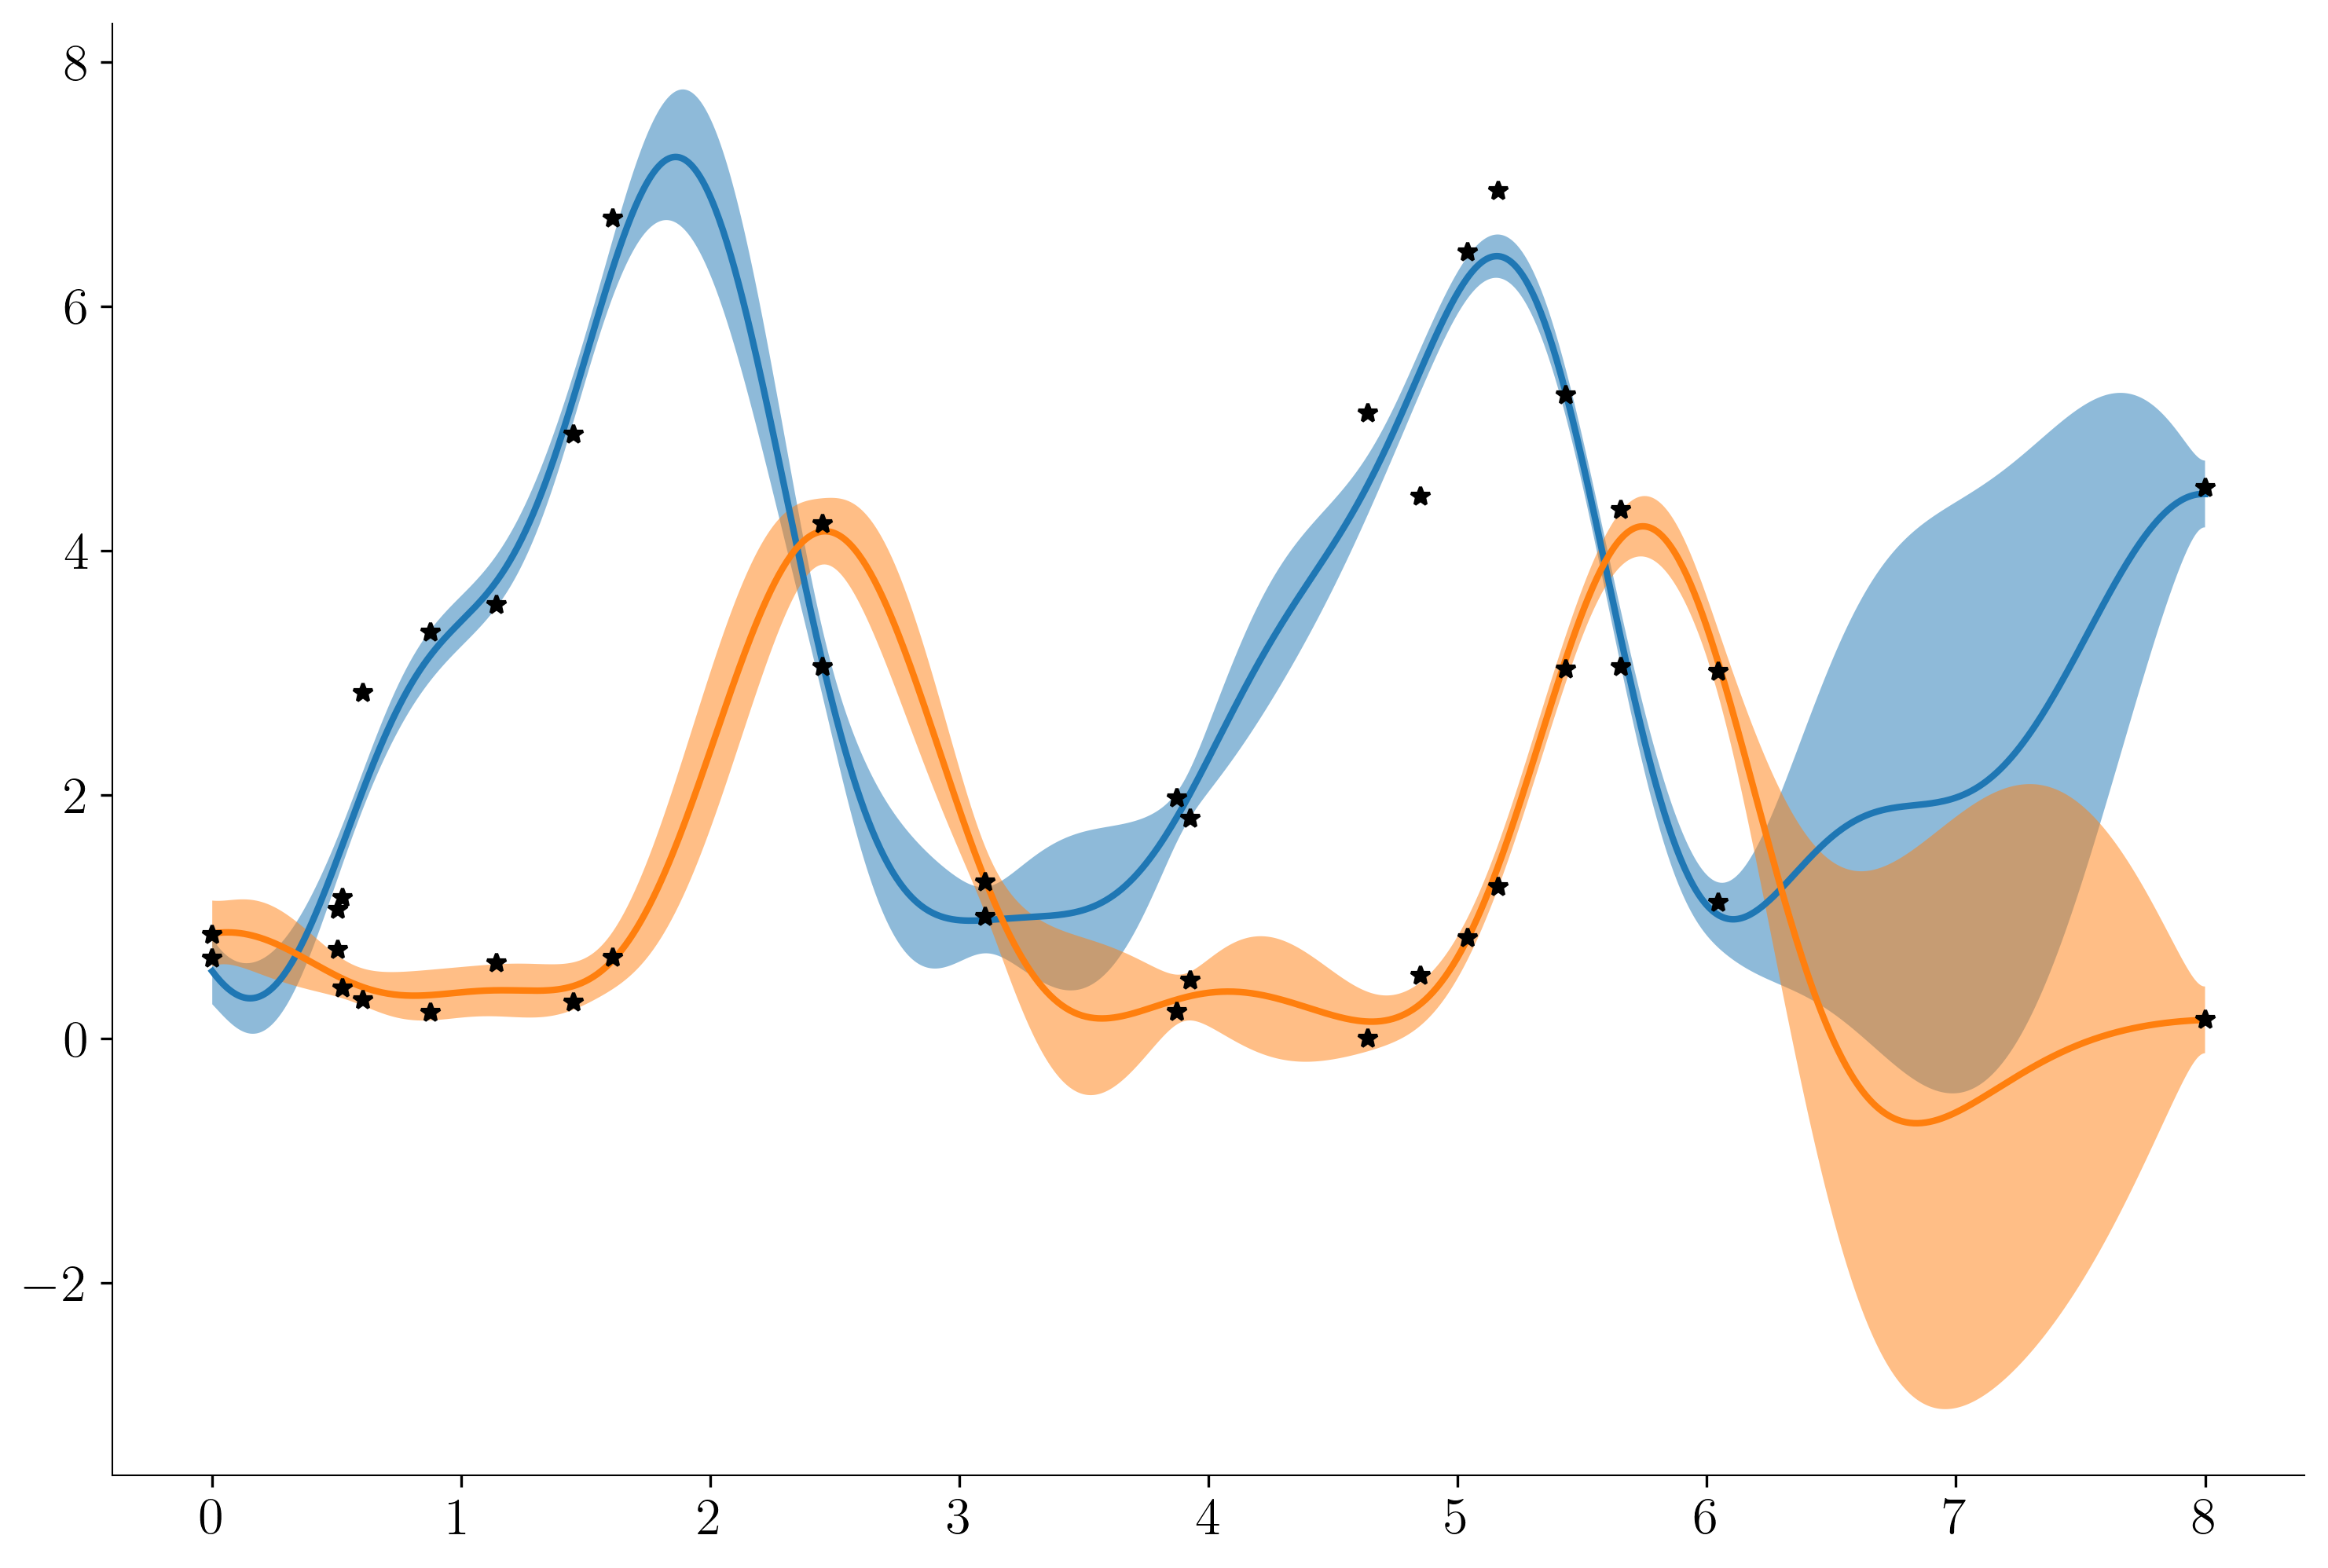

In [74]:
# 2) Initialize raw params (you can pick any real init)
params = {
    'lengthscale': 1.0,    # centered so lengthscale ≈ 1.0
    'variance': 1.0,    # variance ≈ 1.0
    'noise': 1e-2,   # noise ≈ 1e-2
}

raw_params = params_to_raw(params)

optimizer = optax.adam(1e-2)
opt_state = optimizer.init(raw_params)

standardize = True

# 3) One optimization step
def step(raw_params, opt_state, X, y):
    def loss_fn(rp):
        p = raw_to_params(rp)
        loss = 0
        for j in range(y.shape[0]):
            loss += log_marginal_likelihood(p, X, y[j,:], standardize)
        return -1*loss
    loss, grads = jax.value_and_grad(loss_fn)(raw_params)
    updates, opt_state = optimizer.update(grads, opt_state)
    raw_params = optax.apply_updates(raw_params, updates)
    return raw_params, opt_state, loss

# 4) Run your loop exactly as before, but over `raw_params`
for i in range(100):
    raw_params, opt_state, loss = step(raw_params, opt_state, time, y)
    if i % 10 == 0:
        print(f"Iter {i:3d}, neg-log-lik = {loss:.4f}")

# 5) At the end, recover your bounded hyperparams:
final_params = raw_to_params(raw_params)
print(final_params)

Xtest = np.linspace(0,8,1000)[:,None]
for i in range(y.shape[0]):
    post_mu, post_cov = gp_predict(final_params, time, y[i,:], Xtest)
    plt.plot(Xtest, post_mu, lw=2)
    post_std = np.sqrt(np.diag(post_cov))
    plt.fill_between(
        Xtest.flatten(),
        y1 = post_mu - 2*post_std,
        y2 = post_mu + 2*post_std,
        alpha = .5
    )
plt.plot(time, y.T, 'k*')
plt.show()

In [75]:
import jax.numpy as jnp

def k(params, t1, t2):
    """
    RBF kernel: variance * exp(-(t1 - t2)^2 / (2 * lengthscale^2))
    """
    l = params['lengthscale']
    var = params['variance']
    return var * jnp.exp(-(t1 - t2)**2 / (2 * l**2))

def c_dash(params, t1, t2):
    """
    d/dt2 of the RBF kernel
    """
    l2 = params['lengthscale']**2
    return (t1 - t2) / l2 * k(params, t1, t2)

def dash_c(params, t1, t2):
    """
    d/dt1 of the RBF kernel
    """
    l2 = params['lengthscale']**2
    return -(t1 - t2) / l2 * k(params, t1, t2)

def c_double_dash(params, t1, t2):
    """
    d^2/dt1/dt2 of the RBF kernel
    """
    l2 = params['lengthscale']**2
    diff = t1 - t2
    return (1 / l2 - diff**2 / l2**2) * k(params, t1, t2)
# ----------------------------------------------------------------------
# helpers
# ----------------------------------------------------------------------

def _flatten_time(t):
    """Return t with shape (n,) no matter if (n,), (n,1) or (1,n) was given."""
    return jnp.ravel(t)

def _rbf_kernel_no_nugget(params, t):
    """
    Full n×n RBF kernel matrix K_ij = variance * exp(-(t_i-t_j)^2 / (2*ell^2)).
    """
    t    = _flatten_time(t)
    diff = t[:, None] - t[None, :]
    ell2 = params["lengthscale"] ** 2
    return params["variance"] * jnp.exp(-diff**2 / (2.0 * ell2))

# ----------------------------------------------------------------------
# public API – each returns an (n, n) array
# ----------------------------------------------------------------------

def c_phi(params, t, nugget=1e-4):
    """Kernel matrix plus nugget on the diagonal."""
    kmat = _rbf_kernel_no_nugget(params, t)
    return kmat + nugget * jnp.eye(kmat.shape[0])

def c_phi_dash(params, t):
    """Derivative with respect to the second time argument (dt2)."""
    t    = _flatten_time(t)
    diff = t[:, None] - t[None, :]
    ell2 = params["lengthscale"] ** 2
    return (diff / ell2) * _rbf_kernel_no_nugget(params, t)

def dash_c_phi(params, t):
    """Derivative with respect to the first time argument (dt1)."""
    return -c_phi_dash(params, t)

def c_phi_double_dash(params, t):
    """Second mixed derivative with respect to both time arguments."""
    t    = _flatten_time(t)
    diff = t[:, None] - t[None, :]
    ell2 = params["lengthscale"] ** 2
    return (1.0 / ell2 - diff**2 / ell2**2) * _rbf_kernel_no_nugget(params, t)

In [ ]:
print(f'Normal params set to {kernel.theta, kernel.sigma} Jax params set to {final_params}')
kernel.setHyperparams(np.array([final_params['variance'],final_params['lengthscale']]), np.sqrt(final_params['noise']))
print(kernel.theta)

Normal params set to (array([1.13046232, 0.50504847]), np.float64(0.29435004605885295)) Jax params set to {'lengthscale': Array(0.5602605, dtype=float32), 'variance': Array(1.7500963, dtype=float32), 'noise': Array(0.01883809, dtype=float32)}
[1.7500963 0.5602605]


In [86]:
time = np.linspace(0,10,1000)[:,None]
nCPhi = kernel.getCPhi(time)
jCPhi = c_phi(final_params, time)
print(np.all(np.isclose(nCPhi, jCPhi)))
nCPhi_dash = kernel.getCPhiDash(time)
jCPhi_dash = c_phi_dash(final_params, time)
print(np.all(np.isclose(nCPhi_dash, jCPhi_dash)))
nDash_CPhi = kernel.getDashCPhi(time)
jDash_CPhi = dash_c_phi(final_params, time)
print(np.all(np.isclose(nDash_CPhi, jDash_CPhi)))
nDD = kernel.getCPhiDoubleDash(time)
jDD = c_phi_double_dash(final_params, time)
print(np.all(np.isclose(nDD, jDD, rtol=1e-4)))
print(np.isclose(nDD, jDD))

True
False
False
False
[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]]
